# Dynamic Mode Decomposition on Synthetic Pendulum Video

This notebook applies Dynamic Mode Decomposition to a synthetic pendulum video sequence.

The experiment uses a controlled visual system where the true motion is known. The pendulum is useful because its motion is smooth, periodic, and low-dimensional, while the video frames are high-dimensional pixel observations.

The main DMD state representation in this notebook will be a flattened grayscale frame. The synthetic generator creates RGB images for visualization, but DMD is applied to grayscale frames so the state vector has dimension $h \cdot w$ instead of $3hw$. This keeps the experiment simpler and focuses the model on motion structure rather than color-channel variation.

The notebook proceeds through data generation, ground-truth inspection, fit/forecast window selection, snapshot construction, singular-value analysis, DMD fitting, eigenvalue and frequency interpretation, mode visualization, reconstruction, held-out forecasting, background/foreground separation, bob-centroid analysis, coordinate-level forecasting, and rank sensitivity.

The truncation rank $r$ is not fixed at the start. It will be chosen after inspecting the singular values, and later the notebook will compare several ranks to show how $r$ affects reconstruction, forecasting, mode quality, and frequency estimates.


In [1]:
# Imports and Variables
import sys
from pathlib import Path
import json
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name != "DMD":
    raise RuntimeError(f"Expected to run notebook from the DMD folder, got: {PROJECT_DIR}")

HELPERS_DIR = PROJECT_DIR / "helpers"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "synthetic_pendulum"

# Set to True to regenerate the synthetic dataset from scratch.
OVERWRITE_DATA = True

if str(HELPERS_DIR) not in sys.path:
    sys.path.append(str(HELPERS_DIR))

DOCS_IMAGE_DIR = PROJECT_DIR / "docs" / "images"
DOCS_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Verify proper environment is active
print(sys.executable)
print(Path.cwd())

C:\Users\brian\Desktop\GitProjects\DSTopics\DMD\.venv\Scripts\python.exe
C:\Users\brian\Desktop\GitProjects\DSTopics\DMD


## 1. Generate a Synthetic Pendulum Sequence

A helper script generates RGB video frames of a pendulum swinging from a fixed pivot.

Each frame contains:

- a fixed background,
- a pendulum arm,
- and a circular bob.

The generator also saves ground-truth information for every frame, including:

- frame index,
- time,
- pendulum angle,
- angular velocity,
- pivot coordinates,
- bob-center coordinates,
- frame path,
- foreground mask path,
- and bob-only mask path.

This gives us both:

- high-dimensional image data for DMD,
- and known ground truth for evaluating motion and forecasting.

The pendulum bob is the circular weight at the end of the arm. The pivot is the fixed point from which the arm rotates.

The coordinate convention is the standard image convention:

- $(0, 0)$ is the top-left corner of the image,
- $x$ increases to the right,
- $y$ increases downward.

This matters when plotting the bob path, because image coordinates are vertically flipped relative to the usual Cartesian coordinate system.


In [2]:
from make_synthetic_pendulum import PendulumConfig, generate_sequence

config = PendulumConfig(
    num_frames=300,
    fps=30.0,
    frame_width=256,
    frame_height=256,
    amplitude_degrees=26.0,
    period_seconds=2.0,
    damping_per_second=0.0,
    background_mode="plain",
    noise_std=0.0,
    random_seed=42,
)

summary = generate_sequence(
    config=config,
    output_dir=OUTPUT_DIR,
    overwrite=OVERWRITE_DATA,
    save_gif=True,
    readme_gif_path=OUTPUT_DIR / "readme_friendly" / "synthetic_pendulum_preview.gif",
    save_readme_gif=True,
)

summary

{'output_dir': WindowsPath('C:/Users/brian/Desktop/GitProjects/DSTopics/DMD/outputs/synthetic_pendulum'),
 'num_frames': 300,
 'ground_truth_csv': WindowsPath('C:/Users/brian/Desktop/GitProjects/DSTopics/DMD/outputs/synthetic_pendulum/ground_truth.csv'),
 'preview_gif': WindowsPath('C:/Users/brian/Desktop/GitProjects/DSTopics/DMD/outputs/synthetic_pendulum/pendulum_preview.gif'),
 'readme_gif': WindowsPath('C:/Users/brian/Desktop/GitProjects/DSTopics/DMD/outputs/synthetic_pendulum/readme_friendly/synthetic_pendulum_preview.gif')}

## 2. Inspect the Data Before Modeling

Before fitting DMD, the synthetic dataset should be inspected visually and numerically.

Useful initial plots include:

- sample video frames,
- pendulum angle versus time,
- bob $x$ and $y$ coordinates versus time,
- bob path in image coordinates,
- and the fit/forecast split.

This step is important because it establishes what the model is being asked to learn.

The video is high-dimensional because each frame contains many pixels. But the underlying motion is low-dimensional because the pendulum bob is primarily governed by a periodic angle.

That is exactly the kind of situation where DMD should be a reasonable tool: high-dimensional observations with coherent low-dimensional dynamics underneath.


In [3]:
metadata_path = OUTPUT_DIR / "metadata.json"
ground_truth_path = OUTPUT_DIR / "ground_truth.csv"

with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

ground_truth_df = pd.read_csv(ground_truth_path)

display(ground_truth_df.head())
print(json.dumps(metadata["suggested_split"], indent=2))
print("-" * 50)
print(json.dumps(metadata["config"], indent=2))

,frame_index,time_seconds,theta_radians,theta_degrees,theta_dot_radians_per_second,bob_x,bob_y,pivot_x,pivot_y,frame_path,foreground_mask_path,bob_mask_path
0,0,0.000000,0.453786,26.000000,-0.000000,180.604538,147.855286,128,40,frames/frame_0000.png,foreground_masks/foreground_mask_0000.png,bob_masks/bob_mask_0000.png
1,1,0.033333,0.451300,25.857569,-0.149017,180.336260,147.985721,128,40,frames/frame_0001.png,foreground_masks/foreground_mask_0001.png,bob_masks/bob_mask_0001.png
2,2,0.066667,0.443869,25.431838,-0.296401,179.532443,148.371617,128,40,frames/frame_0002.png,foreground_masks/foreground_mask_0002.png,bob_masks/bob_mask_0002.png
3,3,0.100000,0.431576,24.727469,-0.440538,178.196311,148.996928,128,40,frames/frame_0003.png,foreground_masks/foreground_mask_0003.png,bob_masks/bob_mask_0003.png
4,4,0.133333,0.414554,23.752182,-0.579848,176.333785,149.835537,128,40,frames/frame_0004.png,foreground_masks/foreground_mask_0004.png,bob_masks/bob_mask_0004.png


{
  "fit_frames": [
    0,
    209
  ],
  "forecast_frames": [
    210,
    299
  ],
  "fit_frame_count": 210,
  "forecast_frame_count": 90
}
--------------------------------------------------
{
  "num_frames": 300,
  "fps": 30.0,
  "frame_width": 256,
  "frame_height": 256,
  "pivot_x": 128,
  "pivot_y": 40,
  "length_pixels": 120.0,
  "bob_radius": 12,
  "arm_width": 3,
  "amplitude_degrees": 26.0,
  "period_seconds": 2.0,
  "phase_degrees": 0.0,
  "damping_per_second": 0.0,
  "background_mode": "plain",
  "background_color": [
    245,
    245,
    245
  ],
  "arm_color": [
    45,
    45,
    45
  ],
  "bob_color": [
    30,
    80,
    200
  ],
  "grid_spacing": 32,
  "noise_std": 0.0,
  "anti_alias_scale": 4,
  "random_seed": 42
}


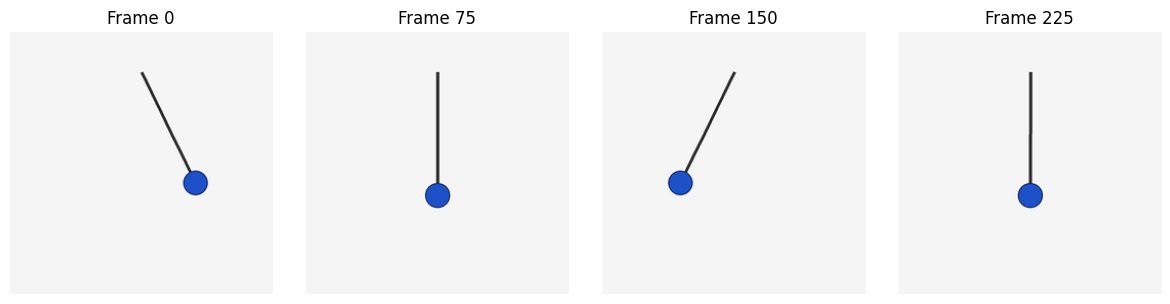

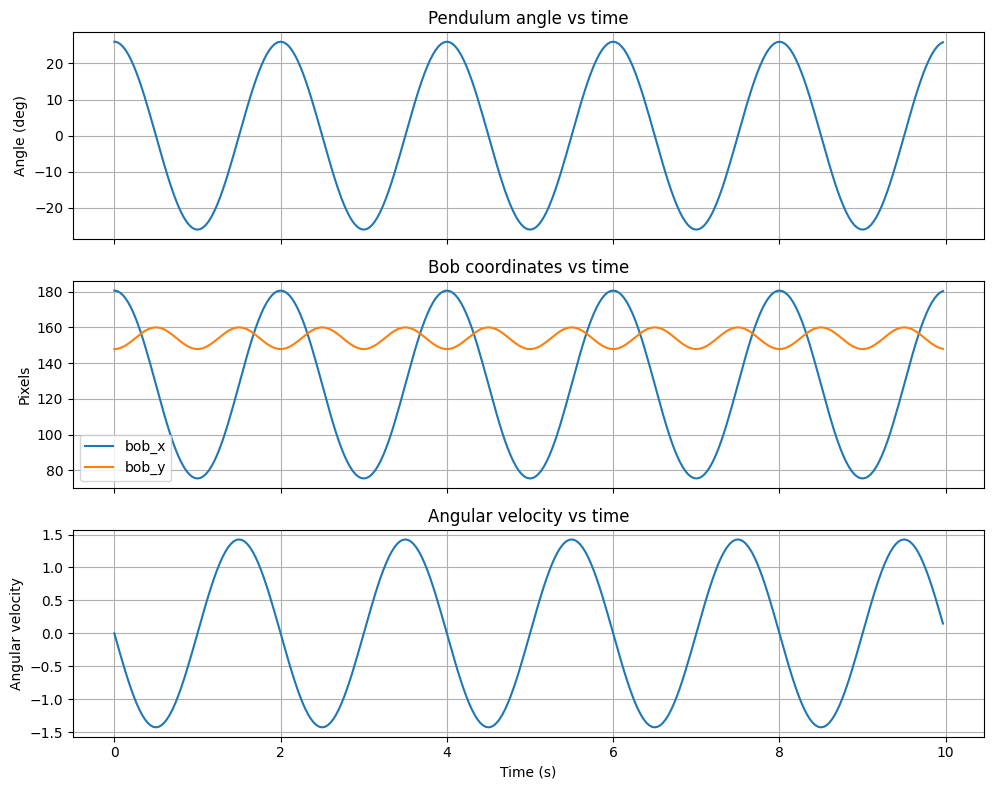

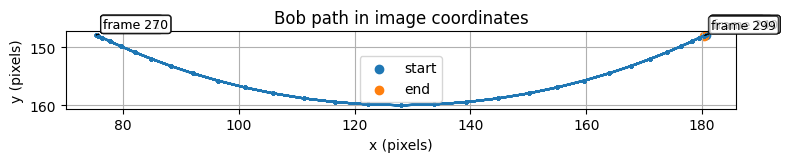

(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Bob path in image coordinates'}, xlabel='x (pixels)', ylabel='y (pixels)'>)

In [4]:
import visualization

frame_paths = [OUTPUT_DIR / path for path in ground_truth_df["frame_path"]]

visualization.show_sample_frames(
    frame_paths=frame_paths,
    frame_indices=[0, len(frame_paths) // 4, len(frame_paths) // 2, 3 * len(frame_paths) // 4],
    figsize=(12, 3),
    save_path=DOCS_IMAGE_DIR / "dmd_pendulum_sample_frames.png",
)

visualization.plot_ground_truth_signals(
    ground_truth_df,
    save_path=DOCS_IMAGE_DIR / "dmd_pendulum_ground_truth_signals.png",
)

visualization.plot_bob_path(
    ground_truth_df,
    figsize=(8, 4),
    show_frame_order=True,
    annotation_mode="frame",
    save_path=DOCS_IMAGE_DIR / "dmd_pendulum_bob_path.png",
)

## 3. Choose a Fitting Window, Forecast Window, and Time Step

The video will be split into a fitting window and a forecast window.

DMD sees only the fitting window. Future frames are held out so that forecasting is a genuine extrapolation test.

For example, if the video has $N$ total frames, we might use the first 70 percent for fitting and the remaining 30 percent for forecasting.

The fitting snapshots are used to build $X$ and $X'$. The held-out snapshots are used only for evaluation.

Although this notebook uses fixed fitting and forecast windows, DMD can also be recomputed on a rolling window as new snapshots arrive, which is one way to adapt the learned linear model over time.

The key choices are:

1. the number of frames used for fitting,
2. the number of frames held out for forecasting,
3. the effective time step $\Delta t$,
4. whether to use every frame or a downsampled sequence.

For the synthetic pendulum, these choices are interpretable. Ideally, the fitting window should include enough motion for DMD to identify the dominant oscillation. If the fitting window is too short, DMD may see only part of the swing and produce poor frequency estimates.

The generated metadata stores each window as inclusive frame endpoints. For example, `[0, 111]` means frames `0` through `111`.

For array slicing, the notebook converts these to Python's half-open convention. Therefore, the fitting window `[0, 111]` becomes `0:112`, and the forecast window `[112, 159]` becomes `112:160`.


In [5]:
# Part 3: Choose fitting window, forecast window, and time step

split = metadata["suggested_split"]
config_metadata = metadata["config"]

fps = float(config_metadata["fps"])
dt = 1.0 / fps

# The metadata stores start/end frame indices inclusively.
fit_start_index, fit_last_index = split["fit_frames"]
forecast_start_index, forecast_last_index = split["forecast_frames"]

# Convert inclusive metadata endpoints into Python's half-open slicing convention.
fit_end_index = fit_last_index + 1
forecast_end_index = forecast_last_index + 1

fit_frame_count = fit_end_index - fit_start_index # this is 'm' below
forecast_frame_count = forecast_end_index - forecast_start_index
total_frame_count = len(ground_truth_df)

fit_start_time = fit_start_index * dt
fit_end_time = fit_end_index * dt
forecast_start_time = forecast_start_index * dt
forecast_end_time = forecast_end_index * dt

split_summary_df = pd.DataFrame(
    [
        {
            "window": "fit",
            "start_frame": fit_start_index,
            "last_frame_inclusive": fit_last_index,
            "slice_end_exclusive": fit_end_index,
            "frame_count": fit_frame_count,
            "start_time_seconds": fit_start_time,
            "end_time_seconds": fit_end_time,
        },
        {
            "window": "forecast",
            "start_frame": forecast_start_index,
            "last_frame_inclusive": forecast_last_index,
            "slice_end_exclusive": forecast_end_index,
            "frame_count": forecast_frame_count,
            "start_time_seconds": forecast_start_time,
            "end_time_seconds": forecast_end_time,
        },
    ]
)

display(split_summary_df)

print(f"fps: {fps}")
print(f"dt: {dt:.6f} seconds/frame")
print(f"total frames: {total_frame_count}")
print(f"fit frames: {fit_start_index} to {fit_last_index} ({fit_frame_count} frames)")
print(f"forecast frames: {forecast_start_index} to {forecast_last_index} ({forecast_frame_count} frames)")

assert fit_start_index == 0
assert fit_end_index == forecast_start_index
assert forecast_end_index <= total_frame_count
assert fit_frame_count > 1
assert forecast_frame_count > 0

,window,start_frame,last_frame_inclusive,slice_end_exclusive,frame_count,start_time_seconds,end_time_seconds
0,fit,0,209,210,210,0.0,7.0
1,forecast,210,299,300,90,7.0,10.0


fps: 30.0
dt: 0.033333 seconds/frame
total frames: 300
fit frames: 0 to 209 (210 frames)
forecast frames: 210 to 299 (90 frames)


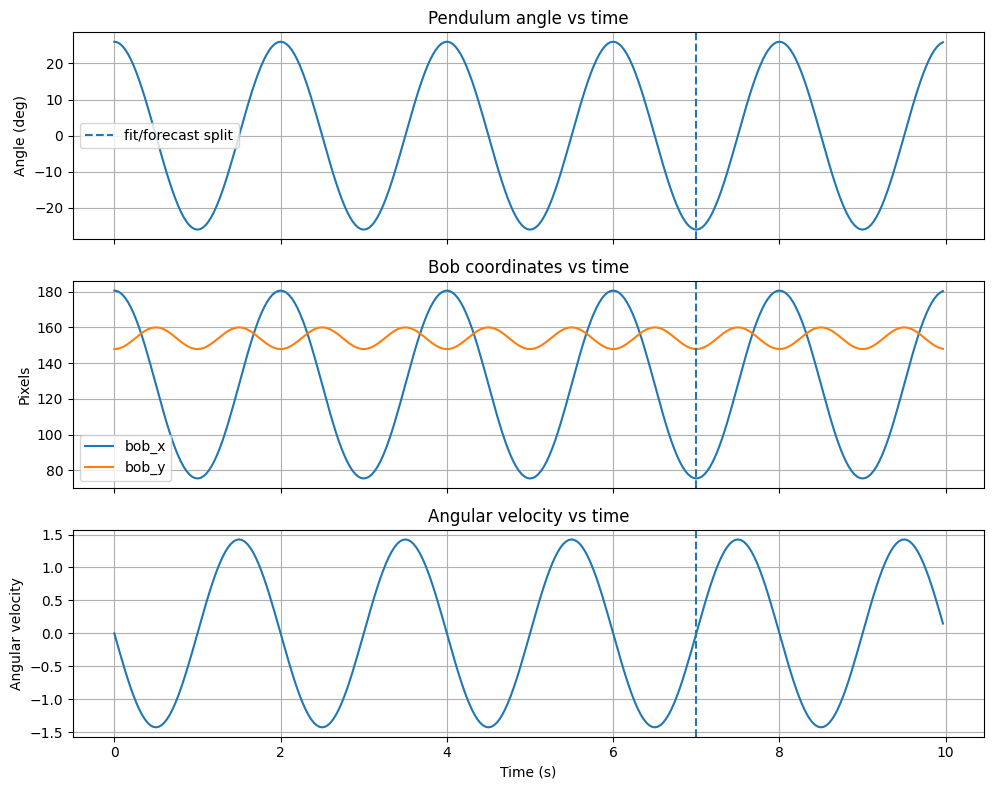

(<Figure size 1000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Pendulum angle vs time'}, ylabel='Angle (deg)'>,
        <Axes: title={'center': 'Bob coordinates vs time'}, ylabel='Pixels'>,
        <Axes: title={'center': 'Angular velocity vs time'}, xlabel='Time (s)', ylabel='Angular velocity'>],
       dtype=object))

In [6]:
visualization.plot_ground_truth_signals(
    ground_truth_df,
    fit_end_index=fit_end_index,
    save_path=DOCS_IMAGE_DIR / "dmd_pendulum_ground_truth_fit_forecast_split.png",
)

## 4. Build the DMD Snapshot Matrices

DMD is fit to grayscale frames rather than RGB frames. This reduces the state dimension from $3hw$ to $hw$, which makes the decomposition cheaper and keeps the interpretation focused on brightness and motion structure. Each frame is flattened into a vector and stacked into a snapshot matrix.

If each frame has height $h$ and width $w$, then each state vector has dimension

$$
n = h \cdot w.
$$

So each grayscale frame becomes

$$
\vec{x}_k \in \mathbb{R}^{n}.
$$

The full video sequence becomes a matrix whose columns are frames:

$$
X_{\text{full}}
=[\vec{x}_1 ; \vec{x}_2 ; \cdots ; \vec{x}_{N}],
$$

where $N$ is the total number of frames.

For fitting DMD, we choose a fitting window containing $m$ snapshots. A raw full-frame DMD fit would form

$$
X = [\vec{x}_1 ; \vec{x}_2 ; \cdots ; \vec{x}_{m-1}]
$$

and

$$
X' = [\vec{x}_2 ; \vec{x}_3 ; \cdots ; \vec{x}_{m}].
$$

DMD would then estimate an approximate linear time-advance relationship:

$$
X' \approx AX.
$$

However, raw video frames often contain a large static component. In this synthetic pendulum video, most pixels belong to the plain background and average scene structure. If we fit DMD directly to raw frames, the largest singular direction is dominated by the static image content rather than the pendulum motion.

To make the full-frame DMD model focus more on motion, this notebook fits DMD to mean-centered frames. First, we compute the average frame over the fitting window:

$$
\bar{\vec{x}}
=\frac{1}{m}
\sum_{k=1}^{m}
\vec{x}_k.
$$

Then each fitting snapshot is centered by subtracting this average frame:

$$
\vec{y}_k
=\vec{x}_k - \bar{\vec{x}}.
$$

The centered fitting matrices are

$$
Y = [\vec{y}_1 ; \vec{y}_2 ; \cdots ; \vec{y}_{m-1}]
$$

and

$$
Y' = [\vec{y}_2 ; \vec{y}_3 ; \cdots ; \vec{y}_{m}].
$$

The DMD model is fit to the centered relationship

$$
Y' \approx AY.
$$

This means the DMD model learns how deviations from the average frame evolve over time. Later, when reconstructing or forecasting frames, the mean frame can be added back so the predicted centered vectors become ordinary grayscale images again:

$$
\hat{\vec{x}}_k
=\bar{\vec{x}} + \hat{\vec{y}}_k.
$$

In this video setting:

* $m$ is the number of snapshots in the DMD fitting window,
* $\Delta t$ is the time between consecutive frames,
* $n$ is the number of pixels in each flattened grayscale frame,
* $\vec{x}_k$ is a raw flattened frame,
* $\bar{\vec{x}}$ is the average fitting-window frame,
* and $\vec{y}_k$ is a mean-centered frame.

The value of $\Delta t$ is determined by the frame rate:

$$
\Delta t = \frac{1}{\text{fps}}.
$$

If frames are skipped or downsampled, then $\Delta t$ must be adjusted accordingly.

A key modeling choice is how we define the state vector. The old saying “garbage in, garbage out” applies here: DMD can only learn dynamics from the representation we give it.

In this notebook, the main state representation is a flattened, mean-centered grayscale frame. This is simple and visually interpretable, but it is not the only possible choice. We could also use RGB frames, cropped frames, downsampled frames, foreground masks, bob-only masks, or even low-dimensional coordinates such as the bob center.

For the full-frame DMD experiment, each DMD prediction is another vector in $\mathbb{R}^n$. Since $n = h \cdot w$, the predicted vector can be reshaped back into an $h \times w$ image and compared directly to the true frame.

The sampling rate also matters. In the original financial version of this project, different bar sizes acted like different temporal views of the data. In the video setting, a similar idea would be to use every frame, every second frame, or every $q$-th frame. Changing this sampling changes the effective $\Delta t$ and therefore changes the physical meaning of one DMD time step.

In this notebook, we begin with a simple single-frame-rate setup for clarity. Later extensions could compare multiple temporal resolutions or use DMD outputs as features for another model, but the main goal here is to evaluate DMD directly through reconstruction, forecasting, mode interpretation, and trajectory comparison.


In [7]:
# Part 4: Build the DMD snapshot matrices

def load_grayscale_frame_as_float(frame_path):
    """Load one RGB frame as a grayscale float array in [0, 1]."""
    with Image.open(frame_path) as image:
        grayscale_image = image.convert("L")
        grayscale_array = np.asarray(grayscale_image, dtype=np.float64) / 255.0

    return grayscale_array


# Load all frames as grayscale images.
grayscale_frames = [load_grayscale_frame_as_float(path) for path in frame_paths]

# Check image dimensions.
h, w = grayscale_frames[0].shape
n = h * w
N = len(grayscale_frames)

# Stack flattened raw frames as columns.
# Shape convention:
# X_full has shape (number of pixels, number of frames) = (n, N)
X_full = np.column_stack([frame.reshape(-1) for frame in grayscale_frames])

# The fitting window contains m snapshots.
m = fit_frame_count

# Extract raw fitting and held-out forecast windows.
X_fit_raw = X_full[:, fit_start_index:fit_end_index]
X_forecast_true = X_full[:, forecast_start_index:forecast_end_index]

# Compute the average fitting-window frame.
# This is subtracted before fitting DMD so the model focuses on motion
# relative to the average image rather than mostly modeling static brightness.
mean_frame_vector = X_fit_raw.mean(axis=1, keepdims=True)

# Center the fitting and forecast windows using the fitting-window mean.
X_fit_centered = X_fit_raw - mean_frame_vector
X_forecast_centered_true = X_forecast_true - mean_frame_vector

# Build the paired DMD snapshot matrices from the centered fitting window.
# Y contains centered snapshots 1 through m-1.
# Y_prime contains centered snapshots 2 through m.
# Use Y notation for mean-centered DMD fitting matrices.
Y_fit_full = X_fit_centered
Y_forecast_true = X_forecast_centered_true

Y = Y_fit_full[:, :-1]
Y_prime = Y_fit_full[:, 1:]

snapshot_summary_df = pd.DataFrame(
    [
        {
            "quantity": "h",
            "meaning": "frame height in pixels",
            "value": h,
        },
        {
            "quantity": "w",
            "meaning": "frame width in pixels",
            "value": w,
        },
        {
            "quantity": "n = h * w",
            "meaning": "flattened grayscale state dimension",
            "value": n,
        },
        {
            "quantity": "N",
            "meaning": "total number of video frames",
            "value": N,
        },
        {
            "quantity": "m",
            "meaning": "number of snapshots in the DMD fitting window",
            "value": m,
        },
        {
            "quantity": "Delta t",
            "meaning": "seconds per frame",
            "value": dt,
        },
    ]
)

display(snapshot_summary_df)

print(f"X_full shape:                   {X_full.shape} = (n, N)")
print(f"X_fit_raw shape:                {X_fit_raw.shape} = (n, m)")
print(f"mean_frame_vector shape:        {mean_frame_vector.shape} = (n, 1)")
print(f"X_fit_centered shape:           {X_fit_centered.shape} = (n, m)")
print(f"Y shape:                        {Y.shape} = (n, m - 1)")
print(f"Y_prime shape:                  {Y_prime.shape} = (n, m - 1)")
print(f"X_forecast_true shape:          {X_forecast_true.shape}")
print(f"X_forecast_centered_true shape: {X_forecast_centered_true.shape}")

assert X_full.shape == (n, N)
assert X_fit_raw.shape == (n, m)
assert mean_frame_vector.shape == (n, 1)
assert X_fit_centered.shape == (n, m)
assert Y.shape == (n, m - 1)
assert Y_prime.shape == (n, m - 1)
assert X_forecast_true.shape[1] == forecast_frame_count
assert X_forecast_centered_true.shape[1] == forecast_frame_count

,quantity,meaning,value
0,h,frame height in pixels,256.000000
1,w,frame width in pixels,256.000000
2,n = h * w,flattened grayscale state dimension,65536.000000
3,N,total number of video frames,300.000000
4,m,number of snapshots in the DMD fitting window,210.000000
5,Delta t,seconds per frame,0.033333


X_full shape:                   (65536, 300) = (n, N)
X_fit_raw shape:                (65536, 210) = (n, m)
mean_frame_vector shape:        (65536, 1) = (n, 1)
X_fit_centered shape:           (65536, 210) = (n, m)
Y shape:                        (65536, 209) = (n, m - 1)
Y_prime shape:                  (65536, 209) = (n, m - 1)
X_forecast_true shape:          (65536, 90)
X_forecast_centered_true shape: (65536, 90)


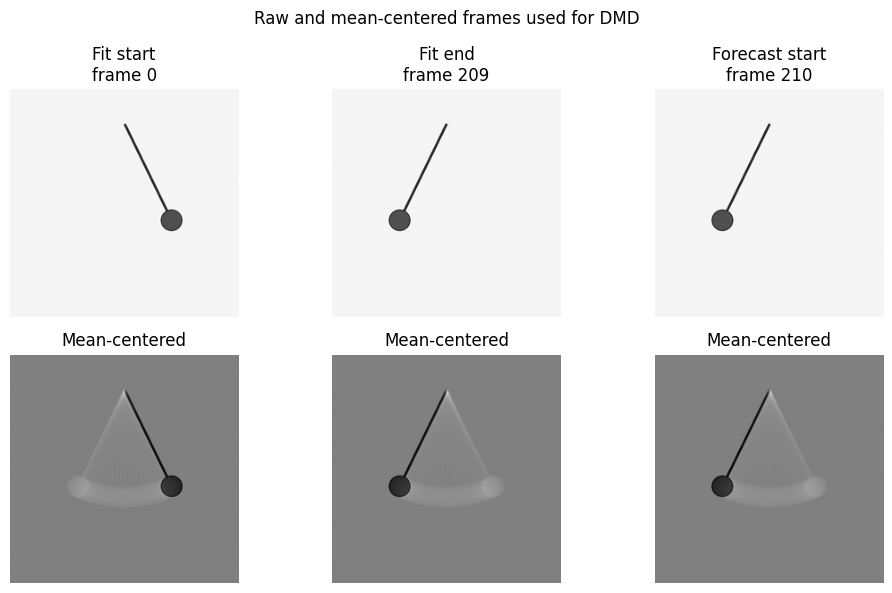

In [8]:
# Plot raw and mean-centered frames as a sanity check

example_indices = [
    fit_start_index,
    fit_end_index - 1,
    forecast_start_index,
]

titles = [
    f"Fit start\nframe {fit_start_index}",
    f"Fit end\nframe {fit_end_index - 1}",
    f"Forecast start\nframe {forecast_start_index}",
]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

centered_display_limit = np.max(np.abs(X_fit_centered))
centered_display_limit = max(centered_display_limit, 1e-8)

for col_index, (frame_index, title) in enumerate(zip(example_indices, titles)):
    raw_frame = X_full[:, frame_index].reshape(h, w)
    centered_frame = (X_full[:, frame_index].reshape(-1, 1) - mean_frame_vector).reshape(h, w)

    axes[0, col_index].imshow(raw_frame, cmap="gray", vmin=0.0, vmax=1.0)
    axes[0, col_index].set_title(title)
    axes[0, col_index].axis("off")

    axes[1, col_index].imshow(
        centered_frame,
        cmap="gray",
        vmin=-centered_display_limit,
        vmax=centered_display_limit,
    )
    axes[1, col_index].set_title("Mean-centered")
    axes[1, col_index].axis("off")

axes[0, 0].set_ylabel("Raw grayscale", fontsize=11)
axes[1, 0].set_ylabel("Centered", fontsize=11)

fig.suptitle("Raw and mean-centered frames used for DMD")
fig.tight_layout()

save_path = DOCS_IMAGE_DIR / "dmd_pendulum_raw_and_centered_snapshot_examples.png"
fig.savefig(save_path, dpi=160, bbox_inches="tight")
plt.show()

## 5. Plot Singular Values and Choose a Rank

Before fitting the main DMD model, we examine the singular values of the centered snapshot matrix. The main rank is chosen here rather than fixed at the beginning, because the singular-value spectrum gives evidence about how much low-rank structure is present after mean-centering.

The singular values show how much centered variation is captured by each singular direction. A sharp decay suggests strong low-rank structure. A slower decay suggests that more directions may be needed to represent the motion accurately.

Because the frames were mean-centered in the previous section, the dominant static image content has been removed from the fitting matrix. The singular values in this section therefore describe variation around the average frame rather than raw pixel brightness in the original video.

For the pendulum video, much of this centered variation should come from motion-related patterns:

- the pendulum arm and bob moving through the frame,
- left-right swing motion,
- moving edges where pixels change from background to pendulum and back,
- and phase-shifted oscillatory structure.

The rank $r$ controls how many singular directions are retained in the reduced DMD model. Candidate ranks might include:

$$
r \in \{2, 4, 8, 16, 24, 32\}.
$$

The rank is not just a compression parameter. It affects both reconstruction and forecasting because it changes the reduced operator whose eigenvalues control the learned dynamics.

A low rank may underfit by keeping too little motion information. A high rank may preserve more image variation, but it is not automatically better for dynamics. Higher ranks can include weak pixel-space directions or numerical artifacts that improve reconstruction of observed frames while making the eigenvalues less physically meaningful.

In earlier iterations, two changes made the DMD setup more informative:

- Mean-centering the frames removed the static-background dominance and made the singular values focus on motion around the average frame.
- Lengthening the synthetic video gave DMD more oscillation cycles to learn from, which is important because the pendulum frequency cannot be estimated well from too little temporal information.

This section therefore uses two pieces of evidence to choose the main rank:

1. the centered singular-value spectrum, which shows how much motion variation is retained, and
2. a small rank-frequency diagnostic, which checks whether different ranks recover a DMD frequency close to the known synthetic pendulum frequency.

The synthetic pendulum has period 2 seconds, so its true frequency is

$$
f_{\text{true}} = \frac{1}{2} = 0.5 \text{ Hz}.
$$

The goal is not to force DMD to know the answer in advance, but to use this controlled synthetic example to evaluate whether the learned eigenvalues are dynamically meaningful. After inspecting the singular values and the rank-frequency diagnostic, we explicitly set the main rank used for the first DMD fit.

In [9]:
# Part 5: Examine singular values before choosing a DMD rank

# Compute the SVD of the mean-centered DMD fitting matrix.
# Y has shape (n, m - 1), where columns are centered fitting snapshots.
U_full, singular_values, Vh_full = np.linalg.svd(Y, full_matrices=False)

# The squared singular values measure variation in the centered snapshots.
# This is centered variation, not raw image brightness energy.
singular_energy = singular_values**2
total_singular_energy = singular_energy.sum()
energy_fraction = singular_energy / total_singular_energy
cumulative_energy_fraction = np.cumsum(energy_fraction)

rank_indices = np.arange(1, len(singular_values) + 1)

# Ratio of the next singular value to the current one.
next_value_ratio = np.full_like(singular_values, fill_value=np.nan, dtype=np.float64)
next_value_ratio[:-1] = singular_values[1:] / singular_values[:-1]

# Drop from the current singular value to the next one.
drop_to_next = np.full_like(singular_values, fill_value=np.nan, dtype=np.float64)
drop_to_next[:-1] = singular_values[:-1] / singular_values[1:]

rank_summary_df = pd.DataFrame(
    {
        "rank": rank_indices,
        "singular_value": singular_values,
        "relative_to_first": singular_values / singular_values[0],
        "energy_fraction": energy_fraction,
        "cumulative_energy_fraction": cumulative_energy_fraction,
        "next_value_ratio": next_value_ratio,
        "drop_to_next": drop_to_next,
    }
)

display(rank_summary_df.head(50))

# Estimate the numerical rank by comparing singular values to a small tolerance.
numerical_tolerance = singular_values[0] * 1e-12
estimated_numerical_rank = int(np.sum(singular_values > numerical_tolerance))

candidate_ranks = [1, 2, 4, 8, 16, 24, 32]
candidate_ranks = [
    candidate_rank
    for candidate_rank in candidate_ranks
    if candidate_rank <= estimated_numerical_rank
]

candidate_rank_summary_df = rank_summary_df.loc[
    rank_summary_df["rank"].isin(candidate_ranks),
    [
        "rank",
        "singular_value",
        "relative_to_first",
        "energy_fraction",
        "cumulative_energy_fraction",
        "drop_to_next",
    ],
].reset_index(drop=True)

display(candidate_rank_summary_df)

energy_thresholds = [0.90, 0.95, 0.99, 0.999]
energy_threshold_rows = []

for threshold in energy_thresholds:
    threshold_rank = int(np.searchsorted(cumulative_energy_fraction, threshold) + 1)
    energy_threshold_rows.append(
        {
            "cumulative_energy_threshold": threshold,
            "smallest_rank_meeting_threshold": threshold_rank,
            "cumulative_energy_at_rank": cumulative_energy_fraction[threshold_rank - 1],
        }
    )

energy_threshold_df = pd.DataFrame(energy_threshold_rows)
display(energy_threshold_df)

largest_drop_index = int(np.nanargmax(drop_to_next[:-1]))
largest_drop_rank = largest_drop_index + 1

print("SVD was computed on the mean-centered DMD fitting matrix Y.")
print(f"Y shape: {Y.shape} = (n, m - 1)")
print(f"Number of singular values: {len(singular_values)}")
print(f"Estimated numerical rank using tolerance {numerical_tolerance:.3e}: {estimated_numerical_rank}")
print(f"Largest singular value: {singular_values[0]:.6f}")
print(f"Second singular value: {singular_values[1]:.6f}")
print(f"Drop from rank 1 to rank 2: {singular_values[0] / singular_values[1]:.2f}x")
print(f"Largest adjacent drop occurs after rank {largest_drop_rank}: {drop_to_next[largest_drop_index]:.2f}x")

assert U_full.shape == (n, len(singular_values))
assert Vh_full.shape == (len(singular_values), m - 1)
assert len(singular_values) == min(n, m - 1)
assert Y.shape == (n, m - 1)

,rank,singular_value,relative_to_first,energy_fraction,cumulative_energy_fraction,next_value_ratio,drop_to_next
0,1,1.156691e+02,1.000000e+00,1.923507e-01,0.192351,8.463990e-01,1.181476e+00
1,2,9.790222e+01,8.463990e-01,1.377984e-01,0.330149,8.832360e-01,1.132200e+00
2,3,8.647077e+01,7.475701e-01,1.074973e-01,0.437646,9.088970e-01,1.100235e+00
3,4,7.859302e+01,6.794642e-01,8.880287e-02,0.526449,8.955093e-01,1.116683e+00
4,5,7.038078e+01,6.084665e-01,7.121430e-02,0.597664,8.925659e-01,1.120365e+00
5,6,6.281949e+01,5.430965e-01,5.673458e-02,0.654398,8.800804e-01,1.136260e+00
6,7,5.528620e+01,4.779686e-01,4.394329e-02,0.698341,8.921297e-01,1.120913e+00
7,8,4.932246e+01,4.264100e-01,3.497426e-02,0.733316,9.025090e-01,1.108022e+00
8,9,4.451397e+01,3.848388e-01,2.848732e-02,0.761803,9.216121e-01,1.085055e+00
9,10,4.102461e+01,3.546721e-01,2.419624e-02,0.785999,9.393061e-01,1.064616e+00


,rank,singular_value,relative_to_first,energy_fraction,cumulative_energy_fraction,drop_to_next
0,1,115.669108,1.000000,0.192351,0.192351,1.181476e+00
1,2,97.902220,0.846399,0.137798,0.330149,1.132200e+00
2,4,78.593019,0.679464,0.088803,0.526449,1.116683e+00
3,8,49.322462,0.426410,0.034974,0.733316,1.108022e+00
4,16,33.234209,0.287321,0.015879,0.895772,1.031234e+00
5,24,23.335557,0.201744,0.007829,0.988189,1.356265e+00
6,32,0.670841,0.005800,0.000006,1.000000,1.680582e+12


,cumulative_energy_threshold,smallest_rank_meeting_threshold,cumulative_energy_at_rank
0,0.900,17,0.910704
1,0.950,21,0.961133
2,0.990,25,0.992445
3,0.999,28,0.999750


SVD was computed on the mean-centered DMD fitting matrix Y.
Y shape: (65536, 209) = (n, m - 1)
Number of singular values: 209
Estimated numerical rank using tolerance 1.157e-10: 32
Largest singular value: 115.669108
Second singular value: 97.902220
Drop from rank 1 to rank 2: 1.18x
Largest adjacent drop occurs after rank 32: 1680581966701.59x


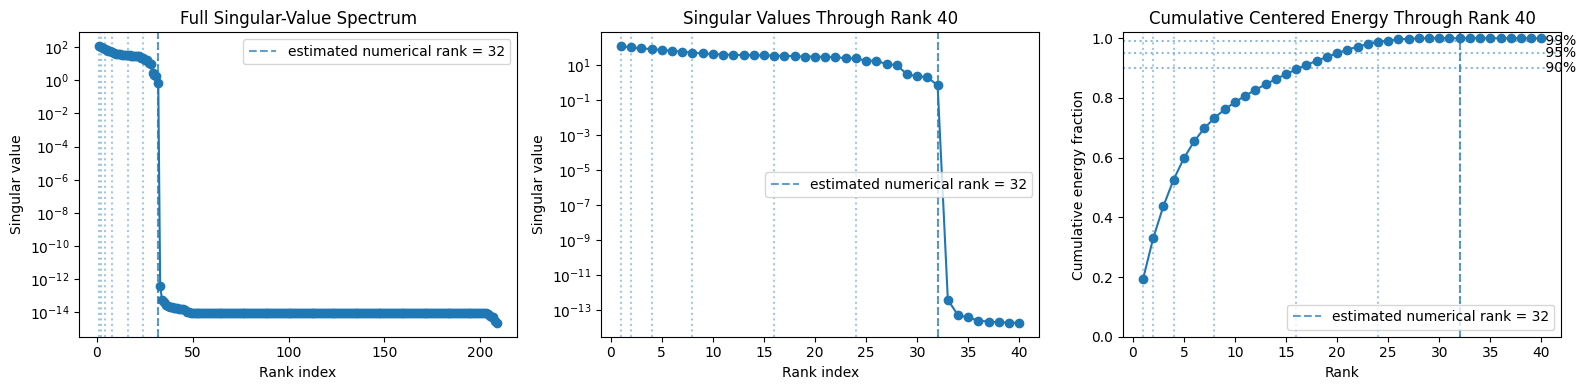

In [10]:
# Plot singular values of the mean-centered DMD fitting matrix

meaningful_rank_limit = min(40, len(singular_values))
meaningful_mask = rank_indices <= meaningful_rank_limit

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full singular-value spectrum.
axes[0].semilogy(rank_indices, singular_values, marker="o")
axes[0].set_title("Full Singular-Value Spectrum")
axes[0].set_xlabel("Rank index")
axes[0].set_ylabel("Singular value")

# Zoom in on the meaningful pre-drop region.
axes[1].semilogy(
    rank_indices[meaningful_mask],
    singular_values[meaningful_mask],
    marker="o",
)
axes[1].set_title(f"Singular Values Through Rank {meaningful_rank_limit}")
axes[1].set_xlabel("Rank index")
axes[1].set_ylabel("Singular value")

# Cumulative centered energy in the meaningful range.
axes[2].plot(
    rank_indices[meaningful_mask],
    cumulative_energy_fraction[meaningful_mask],
    marker="o",
)
axes[2].set_title(f"Cumulative Centered Energy Through Rank {meaningful_rank_limit}")
axes[2].set_xlabel("Rank")
axes[2].set_ylabel("Cumulative energy fraction")
axes[2].set_ylim(0.0, 1.02)

# Mark candidate ranks used for discussion.
for ax in axes:
    for candidate_rank in candidate_ranks:
        ax.axvline(candidate_rank, linestyle=":", alpha=0.4)

# Mark the estimated numerical rank.
for ax in axes:
    ax.axvline(
        estimated_numerical_rank,
        linestyle="--",
        alpha=0.7,
        label=f"estimated numerical rank = {estimated_numerical_rank}",
    )

# Add useful cumulative-energy reference lines.
for threshold in [0.90, 0.95, 0.99]:
    axes[2].axhline(threshold, linestyle=":", alpha=0.5)
    axes[2].text(
        meaningful_rank_limit,
        threshold,
        f" {threshold:.0%}",
        va="center",
    )

for ax in axes:
    ax.legend(loc="best")

fig.tight_layout()

save_path = DOCS_IMAGE_DIR / "dmd_pendulum_centered_singular_values_examination.png"
fig.savefig(save_path, dpi=160, bbox_inches="tight")
plt.show()

In [11]:
# Diagnostic: check whether different ranks recover the true pendulum frequency

def fit_dmd_for_rank(y_prime, singular_values_arr, u_full, vh_full, rank, delta_t):
    """Fit reduced DMD for one rank and return eigenvalues and frequencies."""
    u_rank = u_full[:, :rank]
    singular_values_rank = singular_values_arr[:rank]
    sigma_rank_inv = np.diag(1.0 / singular_values_rank)
    v_rank = vh_full[:rank, :].conj().T

    a_tilde_rank = u_rank.conj().T @ y_prime @ v_rank @ sigma_rank_inv
    eigenvalues_rank, _ = np.linalg.eig(a_tilde_rank)

    lambda_complex_rank = eigenvalues_rank.astype(np.complex128)
    omega_rank = np.log(lambda_complex_rank) / delta_t
    frequency_rank_hz = omega_rank.imag / (2.0 * np.pi)

    return eigenvalues_rank, frequency_rank_hz


true_frequency_hz = 1.0 / float(config_metadata["period_seconds"])
nyquist_frequency_hz = fps / 2.0

rank_test_values = [2, 4, 8, 12, 16, 20, 24, 28, 32]
rank_test_values = [
    rank
    for rank in rank_test_values
    if rank <= estimated_numerical_rank
]

rank_frequency_rows = []

for rank in rank_test_values:
    eigenvalues_rank, frequency_hz_rank = fit_dmd_for_rank(
        y_prime=Y_prime,
        singular_values_arr=singular_values,
        u_full=U_full,
        vh_full=Vh_full,
        rank=rank,
        delta_t=dt,
    )

    positive_frequency_hz = np.abs(frequency_hz_rank)

    # Ignore exactly-zero frequencies when looking for oscillatory modes.
    nonzero_frequency_hz = positive_frequency_hz[positive_frequency_hz > 1e-9]

    if len(nonzero_frequency_hz) > 0:
        closest_frequency_hz = nonzero_frequency_hz[
            np.argmin(np.abs(nonzero_frequency_hz - true_frequency_hz))
        ]
        closest_error_hz = abs(closest_frequency_hz - true_frequency_hz)
    else:
        closest_frequency_hz = np.nan
        closest_error_hz = np.nan

    # Frequencies near Nyquist usually come from negative real eigenvalues,
    # which alternate sign every frame. These are often artifacts rather than
    # meaningful pendulum frequencies.
    nyquist_like_count = int(
        np.sum(np.isclose(positive_frequency_hz, nyquist_frequency_hz, atol=1e-6))
    )

    rank_frequency_rows.append(
        {
            "rank": rank,
            "cumulative_energy_fraction": cumulative_energy_fraction[rank - 1],
            "max_lambda_abs": np.max(np.abs(eigenvalues_rank)),
            "number_complex_eigenvalues": int(np.sum(np.abs(eigenvalues_rank.imag) > 1e-9)),
            "number_nonzero_reported_frequencies": int(len(nonzero_frequency_hz)),
            "nyquist_like_frequency_count": nyquist_like_count,
            "closest_frequency_hz": closest_frequency_hz,
            "closest_error_hz": closest_error_hz,
        }
    )

rank_frequency_df = pd.DataFrame(rank_frequency_rows)

print(f"True pendulum frequency: {true_frequency_hz:.6f} Hz")
print(f"Nyquist frequency at {fps:.1f} fps: {nyquist_frequency_hz:.6f} Hz")

display(rank_frequency_df)

display(
    rank_frequency_df.sort_values(
        "closest_error_hz",
        na_position="last",
    ).reset_index(drop=True)
)

True pendulum frequency: 0.500000 Hz
Nyquist frequency at 30.0 fps: 15.000000 Hz


,rank,cumulative_energy_fraction,max_lambda_abs,number_complex_eigenvalues,number_nonzero_reported_frequencies,nyquist_like_frequency_count,closest_frequency_hz,closest_error_hz
0,2,0.330149,0.983199,2,2,0,0.027780,0.472220
1,4,0.526449,0.977043,4,4,0,0.138215,0.361785
2,8,0.733316,0.977402,8,8,0,0.551062,0.051062
3,12,0.827077,0.975581,6,6,0,0.274769,0.225231
4,16,0.895772,0.976114,14,14,0,0.477508,0.022492
5,20,0.949809,0.978094,0,7,7,15.000000,14.500000
6,24,0.988189,0.978808,0,10,10,15.000000,14.500000
7,28,0.999750,0.983451,0,14,14,15.000000,14.500000
8,32,1.000000,1.000000,2,18,16,7.500000,7.000000


,rank,cumulative_energy_fraction,max_lambda_abs,number_complex_eigenvalues,number_nonzero_reported_frequencies,nyquist_like_frequency_count,closest_frequency_hz,closest_error_hz
0,16,0.895772,0.976114,14,14,0,0.477508,0.022492
1,8,0.733316,0.977402,8,8,0,0.551062,0.051062
2,12,0.827077,0.975581,6,6,0,0.274769,0.225231
3,4,0.526449,0.977043,4,4,0,0.138215,0.361785
4,2,0.330149,0.983199,2,2,0,0.027780,0.472220
5,32,1.000000,1.000000,2,18,16,7.500000,7.000000
6,24,0.988189,0.978808,0,10,10,15.000000,14.500000
7,20,0.949809,0.978094,0,7,7,15.000000,14.500000
8,28,0.999750,0.983451,0,14,14,15.000000,14.500000


After mean-centering, the singular-value spectrum is much more motion-focused. The first singular value no longer dominates the matrix, which confirms that subtracting the average fitting frame removed the overwhelming static image component.

The spectrum decays smoothly through the first several dozen singular values, then drops sharply after rank 32. This suggests that the centered fitting-window data has an effective numerical rank of about 32. The singular values after that point are near machine precision and do not represent meaningful additional video structure.

The smooth decline before rank 32 is expected for full-frame video of a moving object. Even though the pendulum motion is physically simple, the pixel-space representation is more complex: as the arm and bob move, different pixels turn on and off, producing moving edges and shape changes that require multiple singular directions.

The cumulative energy table gives one view of rank selection. Very small ranks are highly compressed, but they discard a substantial amount of centered motion variation. For example, rank 8 keeps only part of the motion structure, while ranks closer to 24 or 32 preserve much more of the centered pixel-space variation.

However, DMD rank should not be chosen from cumulative energy alone. DMD is not only a compression method; it is also a dynamical model. The rank changes the reduced operator, and the reduced operator determines the learned eigenvalues, frequencies, reconstruction behavior, and forecast behavior.

This distinction matters here. Higher rank preserves more image variation, but higher rank is not automatically better for learning the pendulum dynamics. In the rank-frequency diagnostic, some higher-rank models produce frequencies near the Nyquist frequency instead of the true pendulum frequency.

At 30 frames per second, the Nyquist frequency is

$$
f_{\text{Nyquist}} = \frac{\text{fps}}{2} = 15 \text{ Hz}.
$$

A DMD frequency near 15 Hz usually comes from a negative real eigenvalue, whose phase is approximately $\pi$ radians per frame. That corresponds to a mode alternating sign every frame:

$$
+,\; -,\; +,\; -,\; \ldots
$$

This is not the physical pendulum swing. It is usually a sign that the model is representing a high-frequency pixel-space artifact rather than the low-frequency motion we care about.

The synthetic pendulum has period 2 seconds, so the true physical frequency is

$$
f_{\text{true}} = \frac{1}{2} = 0.5 \text{ Hz}.
$$

The rank-frequency diagnostic checks which tested ranks produce a DMD frequency closest to this known value. This does not mean we are giving DMD the answer during fitting. The DMD model is still fit only from the video snapshots. The known frequency is used afterward as a diagnostic because this is a controlled synthetic experiment.

The diagnostic shows that rank 16 gives the closest frequency match among the tested ranks. It is not the rank with the highest cumulative energy, but it gives a better balance between preserving motion structure and learning interpretable dynamics. This is the main reason the notebook uses

$$
r = 16
$$

for the first DMD fit.

This rank choice reflects the experimental iterations that led to the current setup:

- Mean-centering was added to remove static-background dominance and make the SVD focus on motion.
- The synthetic video was lengthened so the fitting window contains more oscillation cycles, giving DMD more temporal evidence for the pendulum frequency.
- The final rank was chosen using both centered-energy retention and frequency recovery, rather than cumulative energy alone.

The key lesson is that the best DMD rank is not necessarily the rank that preserves the most pixel-space energy. A higher rank may reconstruct observed frames better, but it can also introduce weak directions or high-frequency artifacts that make the learned dynamics less physically meaningful.

In [12]:
# Main DMD rank chosen after examining both the singular values
# and a small frequency-recovery rank sweep.
r = 16

true_period_seconds = float(config_metadata["period_seconds"])
true_frequency_hz = 1.0 / true_period_seconds

chosen_rank_frequency_df = rank_frequency_df.loc[
    rank_frequency_df["rank"] == r
].reset_index(drop=True)

print(f"Chosen main DMD rank: r = {r}")
print(f"True pendulum period: {true_period_seconds:.6f} seconds")
print(f"True pendulum frequency: {true_frequency_hz:.6f} Hz")
print(f"Cumulative centered energy captured by rank {r}: {cumulative_energy_fraction[r - 1]:.6f}")
print(f"Singular value at rank {r}: {singular_values[r - 1]:.6f}")
print(f"Next singular value after rank {r}: {singular_values[r]:.6f}")

display(chosen_rank_frequency_df)

assert 1 <= r <= len(singular_values)
assert r <= estimated_numerical_rank
assert r in rank_test_values
assert len(chosen_rank_frequency_df) == 1

Chosen main DMD rank: r = 16
True pendulum period: 2.000000 seconds
True pendulum frequency: 0.500000 Hz
Cumulative centered energy captured by rank 16: 0.895772
Singular value at rank 16: 33.234209
Next singular value after rank 16: 32.227598


,rank,cumulative_energy_fraction,max_lambda_abs,number_complex_eigenvalues,number_nonzero_reported_frequencies,nyquist_like_frequency_count,closest_frequency_hz,closest_error_hz
0,16,0.895772,0.976114,14,14,0,0.477508,0.022492


## 6. Fit DMD

DMD is fit using a rank-$r$ truncated SVD of the mean-centered snapshot matrix.

From the previous section, the raw grayscale frames are denoted by $\vec{x}_k$, and the mean-centered frames are denoted by

$$
\vec{y}_k = \vec{x}_k - \bar{\vec{x}}.
$$

The DMD fitting matrices are built from the centered snapshots:

$$
Y = [\vec{y}_1 \; \vec{y}_2 \; \cdots \; \vec{y}_{m-1}]
$$

and

$$
Y' = [\vec{y}_2 \; \vec{y}_3 \; \cdots \; \vec{y}_{m}].
$$

The goal is to estimate an approximate time-advance relationship:

$$
Y' \approx AY.
$$

Directly forming the full operator $A \in \mathbb{R}^{n \times n}$ would be expensive because $n$ is the number of pixels in one flattened frame. Instead, DMD uses the truncated SVD of $Y$ to work in a much smaller rank-$r$ coordinate system.

The rank-$r$ truncated SVD is

$$
Y \approx U_r \Sigma_r V_r^{\mathrm{H}}.
$$

Here, $V_r^{\mathrm{H}}$ denotes the conjugate transpose of $V_r$. For real-valued data, this is the same as an ordinary transpose.

The reduced DMD operator is

$$
\tilde{A} = U_r^{\mathrm{H}} Y' V_r \Sigma_r^{-1}.
$$

This reduced operator has shape

$$
\tilde{A} \in \mathbb{C}^{r \times r}.
$$

This is much smaller than the full pixel-space operator $A \in \mathbb{R}^{n \times n}$.

The reduced eigenvalue problem is

$$
\tilde{A} W = W \Lambda.
$$

Here:

- $U_r$, $\Sigma_r$, and $V_r$ come from the truncated SVD of $Y$,
- $\tilde{A}$ is the reduced operator,
- $W$ contains eigenvectors of the reduced operator,
- $\Lambda$ contains the DMD eigenvalues,
- and $\Phi$ contains the DMD modes lifted back into full image space.

The full-state DMD modes are computed as

$$
\Phi = Y' V_r \Sigma_r^{-1} W.
$$

Each column of $\Phi$ is a spatial mode with one value per pixel. Since each mode has length $n = h \cdot w$, it can be reshaped into an $h \times w$ image and visualized.

Because this DMD model is fit to mean-centered frames, the modes describe how deviations from the average frame evolve over time. Later, reconstructed or forecasted centered frames will be converted back to ordinary grayscale frames by adding the mean frame back:

$$
\hat{\vec{x}}_k = \bar{\vec{x}} + \hat{\vec{y}}_k.
$$

In [13]:
# Part 6: Fit DMD using the chosen rank r

# Truncated SVD pieces from Y ≈ U Sigma V^H
U_r = U_full[:, :r]
singular_values_r = singular_values[:r]
Sigma_r = np.diag(singular_values_r)
Sigma_r_inv = np.diag(1.0 / singular_values_r)
V_r = Vh_full[:r, :].conj().T

# Reduced DMD operator:
# A_tilde = U_r^H Y_prime V_r Sigma_r^{-1}
A_tilde = U_r.conj().T @ Y_prime @ V_r @ Sigma_r_inv

# Eigen-decomposition of the reduced operator.
# Lambda is stored both as a vector and as a diagonal matrix.
dmd_eigenvalues, W = np.linalg.eig(A_tilde)
Lambda = np.diag(dmd_eigenvalues)

# Exact DMD modes:
# Phi = Y_prime V_r Sigma_r^{-1} W
Phi = Y_prime @ V_r @ Sigma_r_inv @ W

# Continuous-time eigenvalues.
# These are useful for interpreting growth/decay rates and frequencies.
omega = np.log(dmd_eigenvalues.astype(np.complex128)) / dt

# Initial modal amplitudes.
# This solves the centered initial state y_0 approximately as Phi b.
y0 = Y_fit_full[:, 0]
b = np.linalg.lstsq(Phi, y0, rcond=None)[0]

print(f"Chosen rank r: {r}")
print(f"Y shape:          {Y.shape}")
print(f"Y_prime shape:    {Y_prime.shape}")
print(f"U_r shape:        {U_r.shape}")
print(f"Sigma_r shape:    {Sigma_r.shape}")
print(f"V_r shape:        {V_r.shape}")
print(f"A_tilde shape:    {A_tilde.shape}")
print(f"W shape:          {W.shape}")
print(f"Lambda shape:     {Lambda.shape}")
print(f"Phi shape:        {Phi.shape}")
print(f"b shape:          {b.shape}")

assert Y.shape == (n, m - 1)
assert Y_prime.shape == (n, m - 1)
assert U_r.shape == (n, r)
assert Sigma_r.shape == (r, r)
assert V_r.shape == (m - 1, r)
assert A_tilde.shape == (r, r)
assert W.shape == (r, r)
assert Lambda.shape == (r, r)
assert dmd_eigenvalues.shape == (r,)
assert Phi.shape == (n, r)
assert b.shape == (r,)

Chosen rank r: 16
Y shape:          (65536, 209)
Y_prime shape:    (65536, 209)
U_r shape:        (65536, 16)
Sigma_r shape:    (16, 16)
V_r shape:        (209, 16)
A_tilde shape:    (16, 16)
W shape:          (16, 16)
Lambda shape:     (16, 16)
Phi shape:        (65536, 16)
b shape:          (16,)


In [14]:
# Make a DMD eigenvalue and modal-amplitude diagnostic table

lambda_complex = dmd_eigenvalues.astype(np.complex128)
lambda_abs = np.abs(lambda_complex)
lambda_angle_radians = np.angle(lambda_complex)

omega = np.log(lambda_complex) / dt

frequency_hz = omega.imag / (2.0 * np.pi)
period_seconds = np.full_like(frequency_hz, fill_value=np.nan, dtype=np.float64)

nonzero_frequency_mask = np.abs(frequency_hz) > 1e-12
period_seconds[nonzero_frequency_mask] = 1.0 / np.abs(frequency_hz[nonzero_frequency_mask])

dmd_fit_summary_df = pd.DataFrame(
    {
        "mode": np.arange(1, r + 1),
        "lambda_real": lambda_complex.real,
        "lambda_imag": lambda_complex.imag,
        "lambda_abs": lambda_abs,
        "lambda_angle_radians": lambda_angle_radians,
        "omega_real": omega.real,
        "omega_imag": omega.imag,
        "frequency_hz": frequency_hz,
        "period_seconds": period_seconds,
        "amplitude_abs": np.abs(b),
    }
)

dmd_fit_summary_df["distance_from_unit_circle"] = np.abs(lambda_abs - 1.0)

display(
    dmd_fit_summary_df.sort_values(
        ["amplitude_abs", "lambda_abs"],
        ascending=[False, False],
    ).reset_index(drop=True)
)

,mode,lambda_real,lambda_imag,lambda_abs,lambda_angle_radians,omega_real,omega_imag,frequency_hz,period_seconds,amplitude_abs,distance_from_unit_circle
0,11,0.928394,0.000000,0.928394,0.000000,-2.228987,0.000000,0.000000,NaN,248.241780,0.071606
1,12,0.916026,0.000000,0.916026,0.000000,-2.631306,0.000000,0.000000,NaN,237.579232,0.083974
2,10,0.976108,-0.003587,0.976114,-0.003675,-0.725271,-0.110237,-0.017545,56.997154,139.119260,0.023886
3,9,0.976108,0.003587,0.976114,0.003675,-0.725271,0.110237,0.017545,56.997154,139.119260,0.023886
4,13,0.822793,0.014681,0.822924,0.017841,-5.846737,0.535242,0.085186,11.738972,109.196696,0.177076
5,14,0.822793,-0.014681,0.822924,-0.017841,-5.846737,-0.535242,-0.085186,11.738972,109.196696,0.177076
6,15,0.677713,0.033637,0.678547,0.049593,-11.634048,1.487778,0.236787,4.223201,41.339115,0.321453
7,16,0.677713,-0.033637,0.678547,-0.049593,-11.634048,-1.487778,-0.236787,4.223201,41.339115,0.321453
8,8,0.485620,-0.048729,0.488058,-0.100009,-21.519602,-3.000270,-0.477508,2.094206,25.785701,0.511942
9,7,0.485620,0.048729,0.488058,0.100009,-21.519602,3.000270,0.477508,2.094206,25.785701,0.511942


Modes 7 and 8 form a complex-conjugate pair with frequency approximately $\pm 0.4775$ Hz, corresponding to a period of about $2.09$ seconds. This is close to the true synthetic pendulum frequency of $0.5$ Hz and period of $2.0$ seconds; the observed discrete eigenvalue angle is about $\pm 0.1000$ radians/frame, compared with the expected value $\pi/30 \approx 0.1047$ radians/frame.

However, this pair is not a perfectly persistent oscillator. Its eigenvalue magnitude is only about $0.488$, and its continuous-time real part is about $-21.52$, meaning the mode is strongly damped in the DMD model. See the [frequency reporting note](docs/DMD_Background/04_applying_dmd.md#frequency-reporting-in-the-notebook) for more detail on how to interpret these values. This suggests that the rank-16 full-frame DMD model is detecting the oscillatory image pattern associated with the pendulum, but it is still representing moving-pixel video dynamics through a mixture of decaying spatial modes rather than one clean physical pendulum oscillator.

Overall, mean-centering and using a longer video gave DMD enough motion-focused temporal information to recover a near-$0.5$ Hz frequency pair. At the same time, full-frame DMD remains a pixel-space model, so the physical pendulum frequency appears as one component inside a more complicated image-dynamics representation.

## 7. Interpret Eigenvalues and Frequencies

After fitting DMD, the eigenvalues can be plotted in the complex plane. This gives a visual summary of the learned time dynamics.

The discrete DMD eigenvalues $\lambda_i$ describe what happens to each DMD mode after one snapshot step. In this notebook, one snapshot step is one video frame.

A discrete eigenvalue can be written as

$$
\lambda_i = \rho_i e^{i\theta_i}.
$$

Here, $\rho_i = |\lambda_i|$ controls growth or decay per frame, and $\theta_i = \arg(\lambda_i)$ controls phase rotation per frame.

Important interpretations include:

- eigenvalues near the unit circle correspond to persistent behavior,
- eigenvalues inside the unit circle correspond to decay,
- eigenvalues outside the unit circle correspond to growth,
- complex-conjugate pairs correspond to oscillatory behavior,
- eigenvalue angles determine oscillation frequencies.

Because the model is fit to mean-centered frames, these eigenvalues describe the evolution of deviations from the average image, not raw image brightness directly.

The discrete eigenvalues can be converted to continuous-time quantities using

$$
\omega_i = \frac{\log(\lambda_i)}{\Delta t}.
$$

The continuous-time eigenvalue $\omega_i$ separates growth or decay rate from oscillation rate:

$$
\omega_i = \alpha_i + i\beta_i.
$$

Here, $\alpha_i = \mathrm{Re}(\omega_i)$ is the growth or decay rate per second, and $\beta_i = \mathrm{Im}(\omega_i)$ is the angular frequency in radians per second.

Frequency in cycles per second is computed as

$$
f_i = \frac{\mathrm{Im}(\omega_i)}{2\pi}.
$$

The corresponding period is

$$
T_i = \frac{1}{|f_i|}.
$$

For this synthetic pendulum, the true period is 2 seconds, so the true frequency is

$$
f_{\mathrm{true}} = 0.5 \text{ Hz}.
$$

Since the video is sampled at 30 frames per second, the expected discrete eigenvalue angle for the true pendulum frequency is

$$
\theta_{\mathrm{true}}
= 2\pi f_{\mathrm{true}}\Delta t
= 2\pi(0.5)\left(\frac{1}{30}\right)
= \frac{\pi}{30}
\approx 0.1047
$$

radians per frame.

Therefore, a DMD mode pair associated with the visible pendulum swing should have eigenvalue angles near $+\pi/30$ and $-\pi/30$, corresponding to frequencies near $+0.5$ Hz and $-0.5$ Hz.

However, a strong full-frame DMD result does not necessarily mean the pendulum appears as one perfectly persistent oscillator. Full-frame video is a pixel-space representation. As the pendulum arm and bob move, pixels turn on and off, edges shift, and the image dynamics are represented through a mixture of spatial modes.

For this reason, the most useful interpretation is not only whether a mode has high amplitude, but whether the fitted eigenvalues include an oscillatory pair near the known pendulum frequency. The magnitude $|\lambda_i|$ and real part $\mathrm{Re}(\omega_i)$ should also be checked, because a mode pair can have a frequency close to the pendulum motion while still being strongly damped.

This section visualizes the eigenvalues, reports the frequency table, and identifies the mode pair closest to the true pendulum frequency.

In [15]:
import dmd_diagnostics

true_period_seconds = float(config_metadata["period_seconds"])
true_frequency_hz = 1.0 / true_period_seconds

dmd_fit_summary_df = dmd_diagnostics.compute_eigenvalue_diagnostics(
    eigenvalues=dmd_eigenvalues,
    modal_amplitudes=b,
    dt=dt,
    true_frequency_hz=true_frequency_hz,
    fps=fps,
)

display(dmd_fit_summary_df)

closest_frequency_modes_df = dmd_diagnostics.find_closest_frequency_modes(
    dmd_fit_summary_df,
    true_frequency_hz=true_frequency_hz,
)

display(closest_frequency_modes_df)

,mode,lambda_real,lambda_imag,lambda_abs,lambda_angle_radians,omega_real,omega_imag,frequency_hz,abs_frequency_hz,period_seconds,distance_from_unit_circle,amplitude_abs,frequency_error_hz,nyquist_frequency_hz,is_nyquist_like
0,11,0.928394,0.000000,0.928394,0.000000,-2.228987,0.000000,0.000000,0.000000,NaN,0.071606,248.241780,0.500000,15.0,False
1,12,0.916026,0.000000,0.916026,0.000000,-2.631306,0.000000,0.000000,0.000000,NaN,0.083974,237.579232,0.500000,15.0,False
2,10,0.976108,-0.003587,0.976114,-0.003675,-0.725271,-0.110237,-0.017545,0.017545,56.997154,0.023886,139.119260,0.482455,15.0,False
3,9,0.976108,0.003587,0.976114,0.003675,-0.725271,0.110237,0.017545,0.017545,56.997154,0.023886,139.119260,0.482455,15.0,False
4,13,0.822793,0.014681,0.822924,0.017841,-5.846737,0.535242,0.085186,0.085186,11.738972,0.177076,109.196696,0.414814,15.0,False
5,14,0.822793,-0.014681,0.822924,-0.017841,-5.846737,-0.535242,-0.085186,0.085186,11.738972,0.177076,109.196696,0.414814,15.0,False
6,15,0.677713,0.033637,0.678547,0.049593,-11.634048,1.487778,0.236787,0.236787,4.223201,0.321453,41.339115,0.263213,15.0,False
7,16,0.677713,-0.033637,0.678547,-0.049593,-11.634048,-1.487778,-0.236787,0.236787,4.223201,0.321453,41.339115,0.263213,15.0,False
8,8,0.485620,-0.048729,0.488058,-0.100009,-21.519602,-3.000270,-0.477508,0.477508,2.094206,0.511942,25.785701,0.022492,15.0,False
9,7,0.485620,0.048729,0.488058,0.100009,-21.519602,3.000270,0.477508,0.477508,2.094206,0.511942,25.785701,0.022492,15.0,False


,mode,lambda_real,lambda_imag,lambda_abs,lambda_angle_radians,omega_real,omega_imag,frequency_hz,abs_frequency_hz,period_seconds,distance_from_unit_circle,amplitude_abs,frequency_error_hz,nyquist_frequency_hz,is_nyquist_like
0,8,0.48562,-0.048729,0.488058,-0.100009,-21.519602,-3.00027,-0.477508,0.477508,2.094206,0.511942,25.785701,0.022492,15.0,False
1,7,0.48562,0.048729,0.488058,0.100009,-21.519602,3.00027,0.477508,0.477508,2.094206,0.511942,25.785701,0.022492,15.0,False


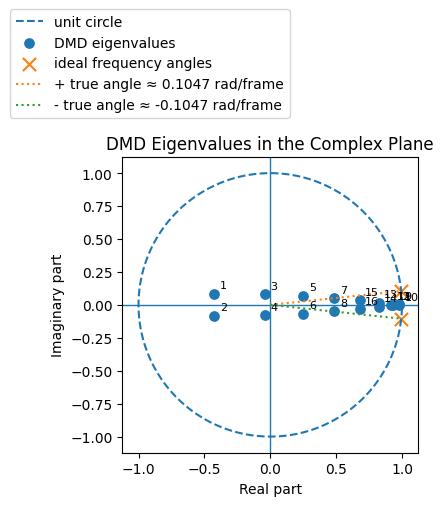

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'DMD Eigenvalues in the Complex Plane'}, xlabel='Real part', ylabel='Imaginary part'>)

In [16]:
dmd_diagnostics.plot_dmd_eigenvalues_complex_plane(
    eigenvalues=dmd_eigenvalues,
    dt=dt,
    true_frequency_hz=true_frequency_hz,
    legend_loc="upper left",
    legend_bbox_to_anchor=(-0.38, 1.5),
    save_path=DOCS_IMAGE_DIR / "dmd_pendulum_eigenvalues_complex_plane.png",
)

Complex-plane eigenvalue plot

The complex-plane plot shows the DMD eigenvalues as points in the plane, with the unit circle included as a reference. Complex-conjugate eigenvalue pairs appear mirrored across the horizontal axis because they have the same real part and opposite imaginary parts. This is expected for oscillatory modes fit from real-valued video data: one member of the pair rotates in the positive direction, and the other rotates in the negative direction.

The ideal pendulum-frequency markers lie close to the unit circle near real part 1, because a perfectly persistent 0.5 Hz oscillator sampled at 30 fps would have eigenvalue angle near $\pm \pi/30$ and magnitude near 1. The DMD eigenvalue pair closest to this angle is modes 7 and 8, with angle about $\pm 0.1000$ radians/frame compared with the expected $\pm 0.1047$ radians/frame. However, those eigenvalues are much closer to the origin than the ideal points because their magnitude is only about $0.488$, meaning the pendulum-frequency component is strongly damped in the full-frame DMD model.

The plot also shows why the result is not a perfect physical oscillator. Several eigenvalues sit inside the unit circle and form a sequence of damped modes, suggesting that the full-frame video dynamics are represented as a mixture of decaying spatial patterns. The high-angle pairs on the left side of the plot, especially modes 1/2 and 3/4, correspond to much higher frequencies and are better interpreted as pixel-space artifacts or residual correction modes than as the physical pendulum swing.

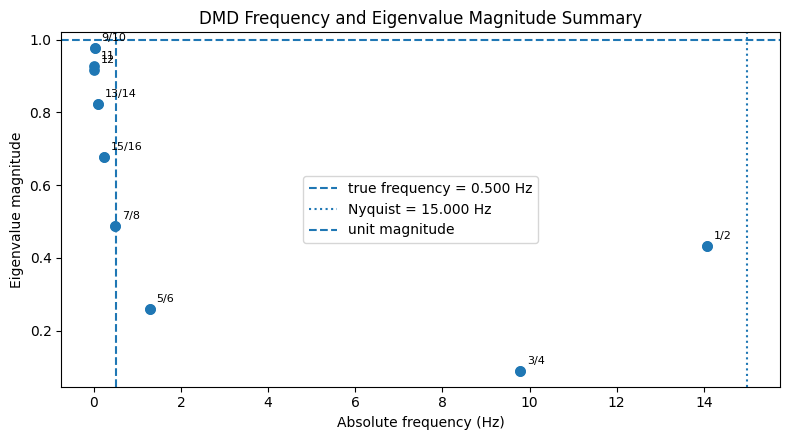

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'DMD Frequency and Eigenvalue Magnitude Summary'}, xlabel='Absolute frequency (Hz)', ylabel='Eigenvalue magnitude'>)

In [17]:
dmd_diagnostics.plot_frequency_magnitude_summary(
    diagnostics_df=dmd_fit_summary_df,
    true_frequency_hz=true_frequency_hz,
    fps=fps,
    save_path=DOCS_IMAGE_DIR / "dmd_pendulum_frequency_magnitude_summary.png",
)

Frequency-magnitude summary plot

The frequency-magnitude plot compares each mode’s absolute frequency against its eigenvalue magnitude. The vertical line at $0.5$ Hz marks the true synthetic pendulum frequency, and the horizontal line at magnitude 1 marks persistent, non-decaying behavior. In an ideal simple oscillator, the most physically meaningful pendulum pair would lie close to the intersection of those two references: frequency near $0.5$ Hz and magnitude near 1.

Modes 7 and 8 are the closest pair to the true frequency, with absolute frequency about $0.4775$ Hz and period about $2.09$ seconds. This is very close to the generated pendulum motion, but the pair lies well below the unit-magnitude line because $|\lambda| \approx 0.488$. That means the rank-16 full-frame DMD model detects the pendulum-like oscillatory pattern, but represents it as a damped image-space component rather than a persistent physical oscillator.

The other nearby low-frequency pairs show a tradeoff. Some modes have eigenvalue magnitudes closer to 1, but their frequencies are much too small, such as the near-zero-frequency modes around $0.0175$ Hz. Other modes move closer to the pendulum-frequency line but become more strongly damped. The far-right pairs, especially modes 3/4 and 1/2, are clear high-frequency outliers; modes 1/2 are close to the 15 Hz Nyquist limit for a 30 fps video and should not be interpreted as the true pendulum swing.

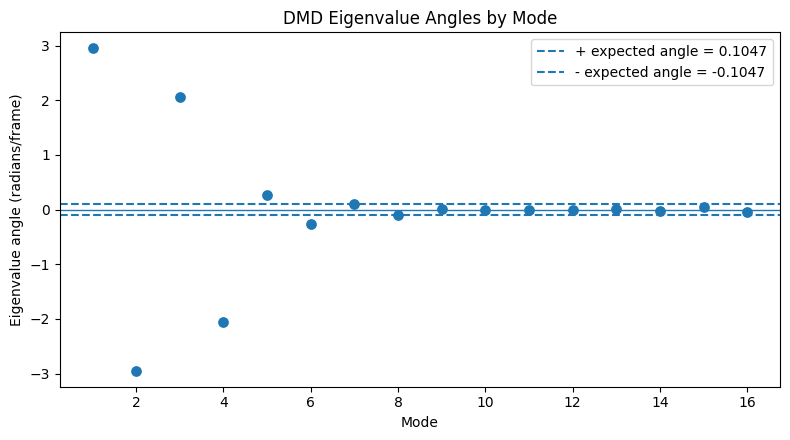

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'DMD Eigenvalue Angles by Mode'}, xlabel='Mode', ylabel='Eigenvalue angle (radians/frame)'>)

In [18]:
dmd_diagnostics.plot_eigenvalue_angle_summary(
    diagnostics_df=dmd_fit_summary_df,
    true_frequency_hz=true_frequency_hz,
    dt=dt,
    save_path=DOCS_IMAGE_DIR / "dmd_pendulum_eigenvalue_angles.png",
)

Eigenvalue-angle summary plot

The eigenvalue-angle plot shows the discrete phase step $\theta$ for each eigenvalue $\lambda = \rho e^{i\theta}$. Positive and negative angles appear in pairs because oscillatory DMD modes usually appear as complex conjugates. The positive member of a pair rotates one direction in the complex plane, while the negative member rotates the opposite direction.

The expected pendulum angle is approximately $\pi/30 \approx 0.1047$ radians/frame. Modes 7 and 8 are the pair that most closely match this expected discrete angle, with observed angles around $\pm 0.1000$ radians/frame. This angle-level comparison is useful because it shows the pendulum match directly in the discrete eigenvalue domain, before converting to continuous-time frequency.

The apparent “horn-like” taper in the angle plot should be interpreted carefully. The mode numbers are labels produced by the eigendecomposition, not a perfect physical ordering from most important to least important. Still, the pattern is informative: the model contains a range of oscillatory components, from high-angle/high-frequency residual modes down to near-zero-angle slow or non-oscillatory modes. The pendulum-relevant pair is not the largest-amplitude pair, but it is the pair whose angle and frequency most closely match the known visible swing.

## 8. Visualize DMD Modes

The DMD modes are high-dimensional vectors. Since each mode has the same dimension as a flattened frame, a mode can be reshaped back into image form.

This allows us to inspect the spatial patterns learned by DMD.

In this notebook, DMD was fit to mean-centered frames:

$$
\vec{y}_k = \vec{x}_k - \bar{\vec{x}}.
$$

Therefore, the DMD modes describe spatial patterns in the deviations from the average image, not raw grayscale frames directly. Later reconstructions and forecasts can be converted back to ordinary image space by adding the mean frame back, but the modes themselves should be interpreted as motion-centered image patterns.

The DMD modes are generally complex-valued. For a complex mode, useful visualizations include:

- the real part of the mode,
- the imaginary part of the mode,
- the magnitude of the mode,
- and the associated eigenvalue frequency and growth or decay rate.

The real and imaginary parts are especially useful for oscillatory mode pairs. A complex-conjugate pair represents a rotating pattern in the complex plane; the real and imaginary components can be interpreted as phase-shifted spatial patterns that combine to produce oscillatory motion over time.

The magnitude of a mode shows where that mode is spatially active, regardless of phase. For video data, this can reveal whether a mode is concentrated around the pendulum arm, the bob, moving edges, or broader image regions.

In this pendulum example, we are especially interested in the mode pair whose frequency is closest to the true pendulum frequency of 0.5 Hz. From the eigenvalue analysis, modes 7 and 8 form the most relevant pair: their frequency is close to the visible pendulum swing, even though the pair is strongly damped. Visualizing these modes helps show where the near-pendulum-frequency dynamics appear in image space.

One important caution is that individual DMD modes should not be interpreted as ordinary video frames. A mode is a spatial pattern tied to a particular temporal behavior. The observed video is reconstructed by combining multiple modes, each evolving according to its eigenvalue and modal amplitude.

See the [DMD mode interpretation notes](docs/DMD_Background/06_complex_dmd_modes_and_conjugate_pairs.md#11-how-complex-mode-parts-combine-into-real-pixel-values) for more explanation and intuition.

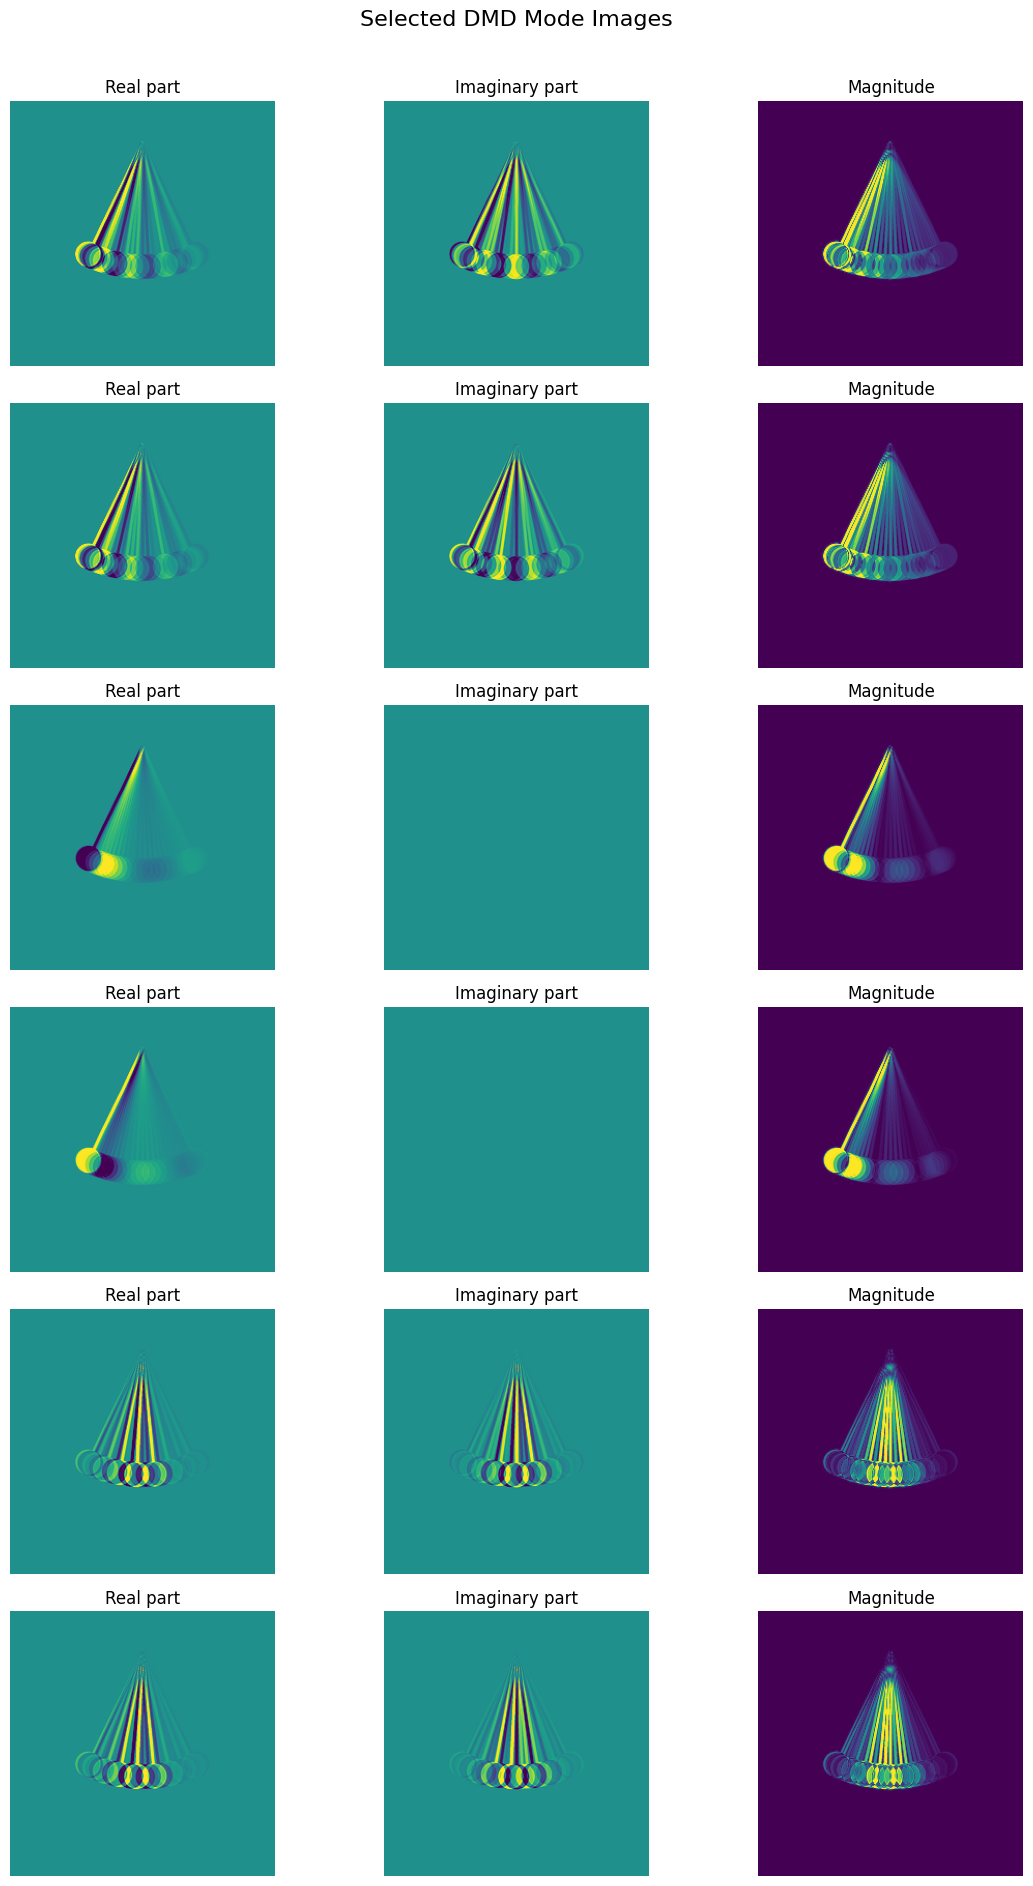

Saved selected DMD mode summary to: C:\Users\brian\Desktop\GitProjects\DSTopics\DMD\docs\images\dmd_pendulum_modes_selected_summary.png


In [19]:
# Part 8: Visualize selected DMD modes
selected_mode_numbers = [
    7,
    8,
    11,
    12,
    1,
    2,
]

mode_summary_save_path = DOCS_IMAGE_DIR / "dmd_pendulum_modes_selected_summary.png"

fig, axes = dmd_diagnostics.plot_dmd_mode_images(
    Phi=Phi,
    mode_numbers=selected_mode_numbers,
    frame_shape=(h, w),
    diagnostics_df=dmd_fit_summary_df,
    save_path=mode_summary_save_path,
    percentile=99.0,
)

print(f"Saved selected DMD mode summary to: {mode_summary_save_path}")

## 9. Reconstruct Observed Motion

The first evaluation is reconstruction.

Reconstruction asks:

> Can DMD reproduce the pendulum frames used during fitting?

Using the learned modes and eigenvalues, the notebook reconstructs frames in the fitting window.

The reconstructed frames can be compared to the true frames using:

- side-by-side visual comparisons,
- absolute error images,
- mean squared error,
- mean absolute error,
- and error over time.

Reconstruction quality tells us how well the selected rank-$r$ DMD model explains the observed training-window dynamics.

Good reconstruction does not necessarily imply good forecasting. A model can fit observed frames well while still extrapolating poorly.

In [ ]:
# Part 9 code

## 10. Forecast Future Frames

After fitting DMD on an initial window of frames, the model is used to extrapolate beyond the fitting window.

This gives a direct test of DMD as a forecasting method.

Starting from a recent observed state $\vec{x}_k$, we can forecast $s$ steps ahead using

$$
\vec{x}_{k+s}
\approx
\Phi \Lambda^s \vec{b}_k,
$$

where

$$
\vec{b}_k = \Phi^\dagger \vec{x}_k.
$$

The predicted future frames can be compared against held-out true frames.

Useful diagnostics include:

- true future frame versus predicted future frame,
- absolute error images,
- forecast MSE versus horizon,
- forecast MAE versus horizon,
- and visual inspection of phase drift.

Forecasting is harder than reconstruction because small errors in eigenvalue magnitude or phase accumulate over time.

For periodic motion, the forecast should remain coherent over short horizons when the learned DMD frequency is close to the true pendulum frequency.

In [ ]:
# Part 10 code

## 11. Background/Foreground Separation

DMD can also be used for a simple form of background/foreground separation.

The idea is:

- background-like content should be persistent or slowly varying,
- moving foreground content should require oscillatory or higher-frequency modes.

A simple DMD-based decomposition is:

$$
\text{background} \approx \text{low-frequency DMD reconstruction}
$$

and

$$
\text{foreground} \approx \text{original frame} - \text{background reconstruction}.
$$

For the synthetic pendulum, the stationary background should be captured by persistent modes, while the arm and bob should appear in the foreground residual.

The generator also provides true foreground masks and bob-only masks, which can be used for qualitative comparison.

This section should be interpreted carefully. DMD does not know what an object is. It does not semantically identify the bob or arm. It separates components based on temporal behavior.

In [ ]:
# part 11 code

## 12. Bob-Centroid Motion Analysis

Because the synthetic generator saves the true bob-center coordinates, the predicted motion can also be evaluated geometrically.

The ground-truth trajectory is given by the true bob coordinates:

$$
(x_{\text{bob}}(t), y_{\text{bob}}(t)).
$$

There are two related ways to use this information.

First, the true bob coordinates can be plotted directly to show the real pendulum path.

Second, a simple image-processing step can estimate the bob location from reconstructed or forecasted frames. The estimated bob path can then be compared against the true path from the generator.

Useful diagnostics include:

- true bob path versus estimated bob path,
- Euclidean centroid error over time,
- RMSE of the predicted centroid path,
- and comparison of trajectory shape.




In [ ]:
# part 12 code

## 13. Coordinate-Level DMD and Constant-Velocity Baseline

The following is a lower-dimensional coordinate-forecasting experiment. Instead of applying DMD to full frames, we can apply DMD to the bob-coordinate time series.

A simple coordinate state is

$$
\vec{z}_k =
\begin{bmatrix}
x_k \\
y_k
\end{bmatrix}.
$$

A richer delay-coordinate state is

$$
\vec{z}_k =
\begin{bmatrix}
x_k \\
y_k \\
x_{k-1} \\
y_{k-1} \\
\vdots \\
x_{k-q} \\
y_{k-q}
\end{bmatrix}.
$$

This delay-coordinate construction gives DMD temporal memory and is related to Hankel-DMD ideas.

Coordinate-level forecasting is often cleaner than full-frame forecasting because it models the low-dimensional motion directly rather than trying to forecast every pixel.

A useful baseline comparison is a constant-velocity forecast. Constant velocity may work briefly, but it should struggle near pendulum turning points where the direction of motion changes.

In [ ]:
# part 13 code

## 14. Rank Sensitivity Study

The notebook will also study how the choice of DMD rank affects results.

Candidate ranks might include:

$$
r \in \{2, 4, 8, 16\}.
$$

For each rank, useful quantities include:

- reconstruction error,
- forecast error,
- dominant DMD frequency,
- stability of eigenvalues,
- and visual quality of predicted frames.

This helps demonstrate that DMD is not just a single push-button method. The rank controls the balance between compression, reconstruction quality, and forecast stability.

The expected behavior is:

- very low rank may underfit the pendulum motion,
- moderate rank may capture the dominant background and oscillatory dynamics,
- very high rank may fit the training frames better but include unstable or less meaningful modes.

In [ ]:
# part 14 code

## Part 15: Final Summary and Limitations

A synthetic pendulum is a strong instructional example for DMD because:

- the system has coherent periodic dynamics,
- the video frames are high-dimensional but generated from low-dimensional motion,
- the true future states are known,
- the true bob trajectory is known,
- the results can be evaluated visually and numerically,
- the dominant frequency can be compared against the known pendulum period,
- and the learned modes can be reshaped into interpretable images.

This makes the experiment better aligned with DMD's strengths: learning dominant spatiotemporal structure from sequential data.

The strongest results to look for are:

- singular-value decay showing low-rank structure,
- eigenvalues on or near the unit circle,
- a dominant DMD frequency close to the true pendulum frequency,
- DMD modes that reveal static and oscillatory structure,
- accurate reconstruction inside the fitting window,
- short-horizon frame forecasts that remain visually coherent,
- forecast error increasing with horizon due to phase or eigenvalue errors,
- and coordinate-level forecasts that capture the bob path.

DMD is useful here because the observations are high-dimensional, but the underlying dynamics are coherent, structured, and low-dimensional.

The limitations are also important:

- the setup is synthetic and controlled,
- real video would introduce lighting changes, camera motion, occlusion, segmentation difficulty, and measurement noise,
- DMD is linear in the chosen state space,
- and long-horizon forecasts can degrade when small eigenvalue or phase errors accumulate.

The purpose of this notebook is therefore not to claim that DMD solves arbitrary video forecasting. The purpose is to show, step by step, how DMD connects linear algebra, dynamical systems, SVD, eigenvalues, video data, and interpretable forecasting.

## References

Content inspired by course lecture notes and material in __[1]__.

__[1]__ Steven L. Brunton; J. Nathan Kutz (2019). "Data Driven Science and Engineering: Machine Learning, Dynamical Systems, and Control". Section 3.7.

__[2]__ M. Gavish and D. L. Donoho, "The Optimal Hard Threshold for Singular Values is $4 / \sqrt{3}$" in IEEE Transactions on Information Theory, vol. 60, no. 8, pp. 5040-5053, Aug. 2014, doi: 10.1109/TIT.2014.2323359.